# **Distance Metrics and Similarity Design for Recommendation Systems**

---
**Group:** Numpy   
**Author:** Thanh Le

## **Import Libraries**

In [132]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans

## **1. Data Overview & Preprocessing**
The objective of this section is to load the dataset, inspect its basic structure, check for any missing values, and remove unnecessary features.

link dataset: https://www.kaggle.com/datasets/aksahaha/crop-recommendation

**Steps Performed:**
1. Read the dataset from the CSV file.
2. Check for Null/Missing values across all features.
3. Remove redundant or uninformative columns (`Unnamed: 8`, `Unnamed: 9`).
4. Inspect data types (`dtypes`) to ensure all features are numeric and ready for distance metric calculations.

### Step 1: Read the dataset from the CSV file

In [133]:
# mount to drive to get dataset
drive.mount('/content/mydrive')

Drive already mounted at /content/mydrive; to attempt to forcibly remount, call drive.mount("/content/mydrive", force_remount=True).


In [134]:
# get dataset and view data structure and shape
df = pd.read_csv("/content/mydrive/MyDrive/AIO2026/Dataset/Crop_recommendation.csv");
print(df.head()) # xem default 5 rows đầu của data
print(df.shape)

   Nitrogen  phosphorus  potassium  temperature   humidity        ph  \
0        90          42         43    20.879744  82.002744  6.502985   
1        85          58         41    21.770462  80.319644  7.038096   
2        60          55         44    23.004459  82.320763  7.840207   
3        74          35         40    26.491096  80.158363  6.980401   
4        78          42         42    20.130175  81.604873  7.628473   

     rainfall label  Unnamed: 8  Unnamed: 9  
0  202.935536  rice         NaN         NaN  
1  226.655537  rice         NaN         NaN  
2  263.964248  rice         NaN         NaN  
3  242.864034  rice         NaN         NaN  
4  262.717340  rice         NaN         NaN  
(2200, 10)


### Step 2: Check for Null/missing vallues in the features

In [135]:
print(df.isnull().sum())

Nitrogen          0
phosphorus        0
potassium         0
temperature       0
humidity          0
ph                0
rainfall          0
label             0
Unnamed: 8     2200
Unnamed: 9     2200
dtype: int64


### Step 3: Remove unnecessary columns

In [136]:
# remove null cols
new_df = df.drop(columns=['Unnamed: 8', 'Unnamed: 9'], axis=1, inplace=False)
print(new_df.isnull().sum())
print(new_df.shape)

Nitrogen       0
phosphorus     0
potassium      0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
(2200, 8)


### Step 4: View `dtype` of each feature

In [137]:
print(new_df.dtypes)

Nitrogen         int64
phosphorus       int64
potassium        int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object


## **2. Summary Statistics**


In [138]:
new_df.describe().round(2)

,Nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,25.62,71.48,6.47,103.46
std,36.92,32.99,50.65,5.06,22.26,0.77,54.96
min,0.00,5.00,5.00,8.83,14.26,3.50,20.21
25%,21.00,28.00,20.00,22.77,60.26,5.97,64.55
50%,37.00,51.00,32.00,25.60,80.47,6.43,94.87
75%,84.25,68.00,49.00,28.56,89.95,6.92,124.27
max,140.00,145.00,205.00,43.68,99.98,9.94,298.56


**Interpretation:**
- `describe()` provides a comprehensive overview of the value ranges (min, max), means, and standard deviations (`std`) and the quartiles for each feature.

**Remarks:**
- **Significant scale differences:** There is a large difference in features. For instance, `ph` only ranges from 3.50 to 9.94, while `rainfall` spans from 20.21 to 298.56. So this should be applied some scaler to normalize the data before using distance metrics to avoid the domination in distance calculations.

In [139]:
new_df['label'].value_counts() # shows that all data is balance :)

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


**Interpretation:**
- `value_counts()` on the `label` to count the total samples of that label value.

**Remarks:**
- **Perfect label balance:** The dataset contains exactly 100 samples for each of the 22 crop types.

## **3. Feature Distributions**

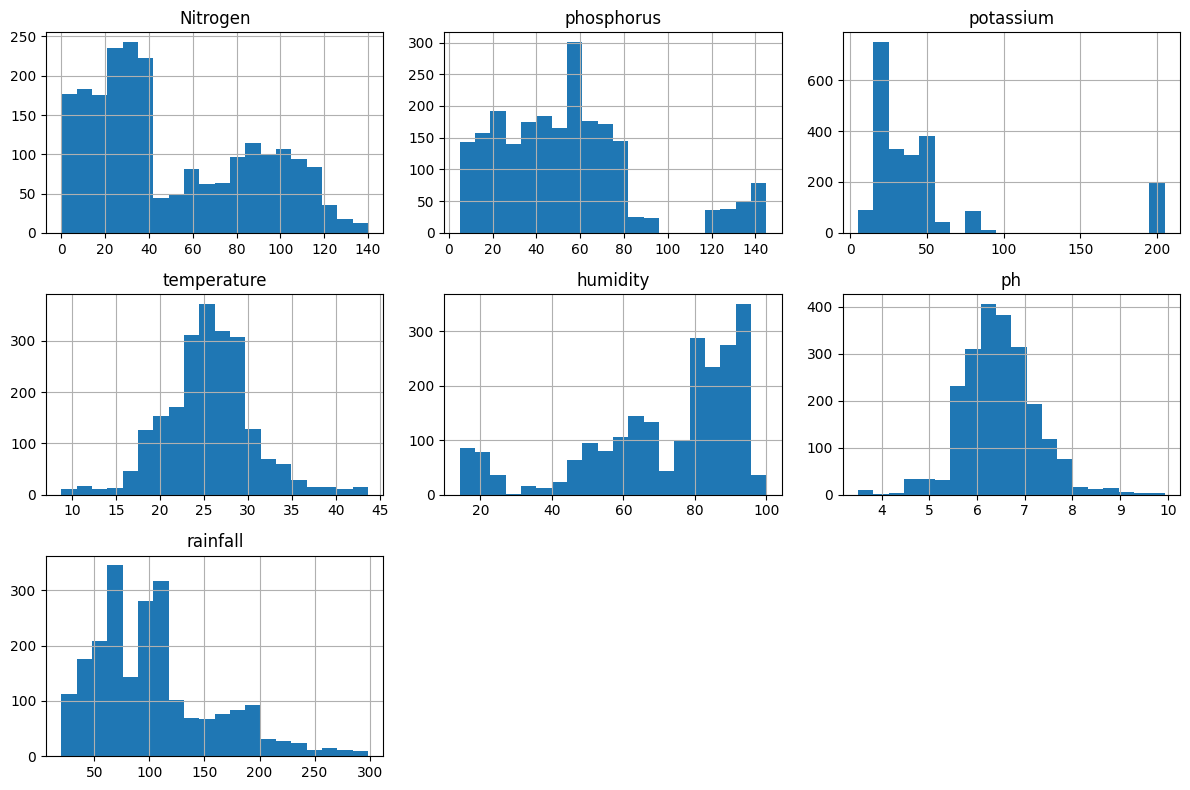

In [140]:
new_df.hist(
    figsize=(12, 8),
    bins=20
)

plt.tight_layout()
plt.show()

**Interpretation:**
- `Phosphorus` and `potassium` exhibit have right-skewed distributions, heavily concentrated at lower values (0-50) but stretching to extreme maximums of **145** and **205**, respectively. This shows that only a few specific crops demand high doses of these minerals.
- `Rainfall` is right-skewed and unevenly distributed, heavily clustered around **50mm to 100mm**. This shows that most crops thrive on low-to-moderate water levels, whereas a few outliers require heavy flooding.
- `Humidity` is left-skewed, with data densely clustered at the higher end (**80% to 100%**) and a maximum of **99.98%**, reflecting that most crops evaluated are tropical and depend on highly humid environments.
- **Temperature** and **pH** show symmetrical, bell-shaped distributions. This demonstrates that the majority of crops share a similar, narrow comfort zone for temperature (around **25 °C**) and soil pH (around **6.5**).

**Remarks:**
- The extreme maximums in skewed features (e.g., **potassium** reaching **205**, **rainfall** reaching **298.56**) will easily dominate and misleading distance calculations.

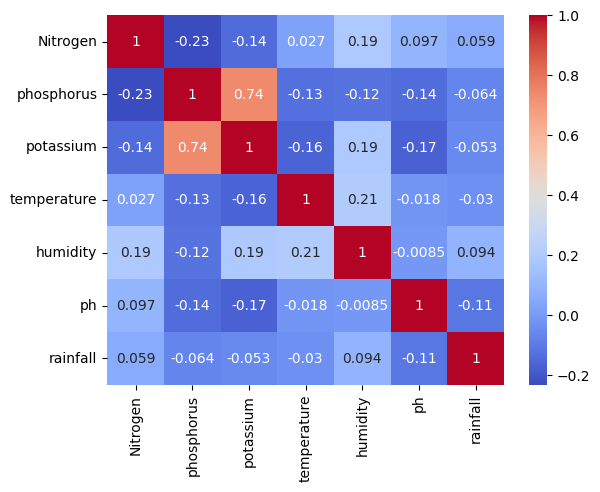

In [141]:
sns.heatmap(
    new_df.drop('label', axis=1).corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

In [142]:
grouped = new_df.groupby('label').mean().round(2)
print(grouped)

             Nitrogen  phosphorus  potassium  temperature  humidity    ph  \
label                                                                       
apple           20.80      134.22     199.89        22.63     92.33  5.93   
banana         100.23       82.01      50.05        27.38     80.36  5.98   
blackgram       40.02       67.47      19.24        29.97     65.12  7.13   
chickpea        40.09       67.79      79.92        18.87     16.86  7.34   
coconut         21.98       16.93      30.59        27.41     94.84  5.98   
coffee         101.20       28.74      29.94        25.54     58.87  6.79   
cotton         117.77       46.24      19.56        23.99     79.84  6.91   
grapes          23.18      132.53     200.11        23.85     81.88  6.03   
jute            78.40       46.86      39.99        24.96     79.64  6.73   
kidneybeans     20.75       67.54      20.05        20.12     21.61  5.75   
lentil          18.77       68.36      19.41        24.51     64.80  6.93   

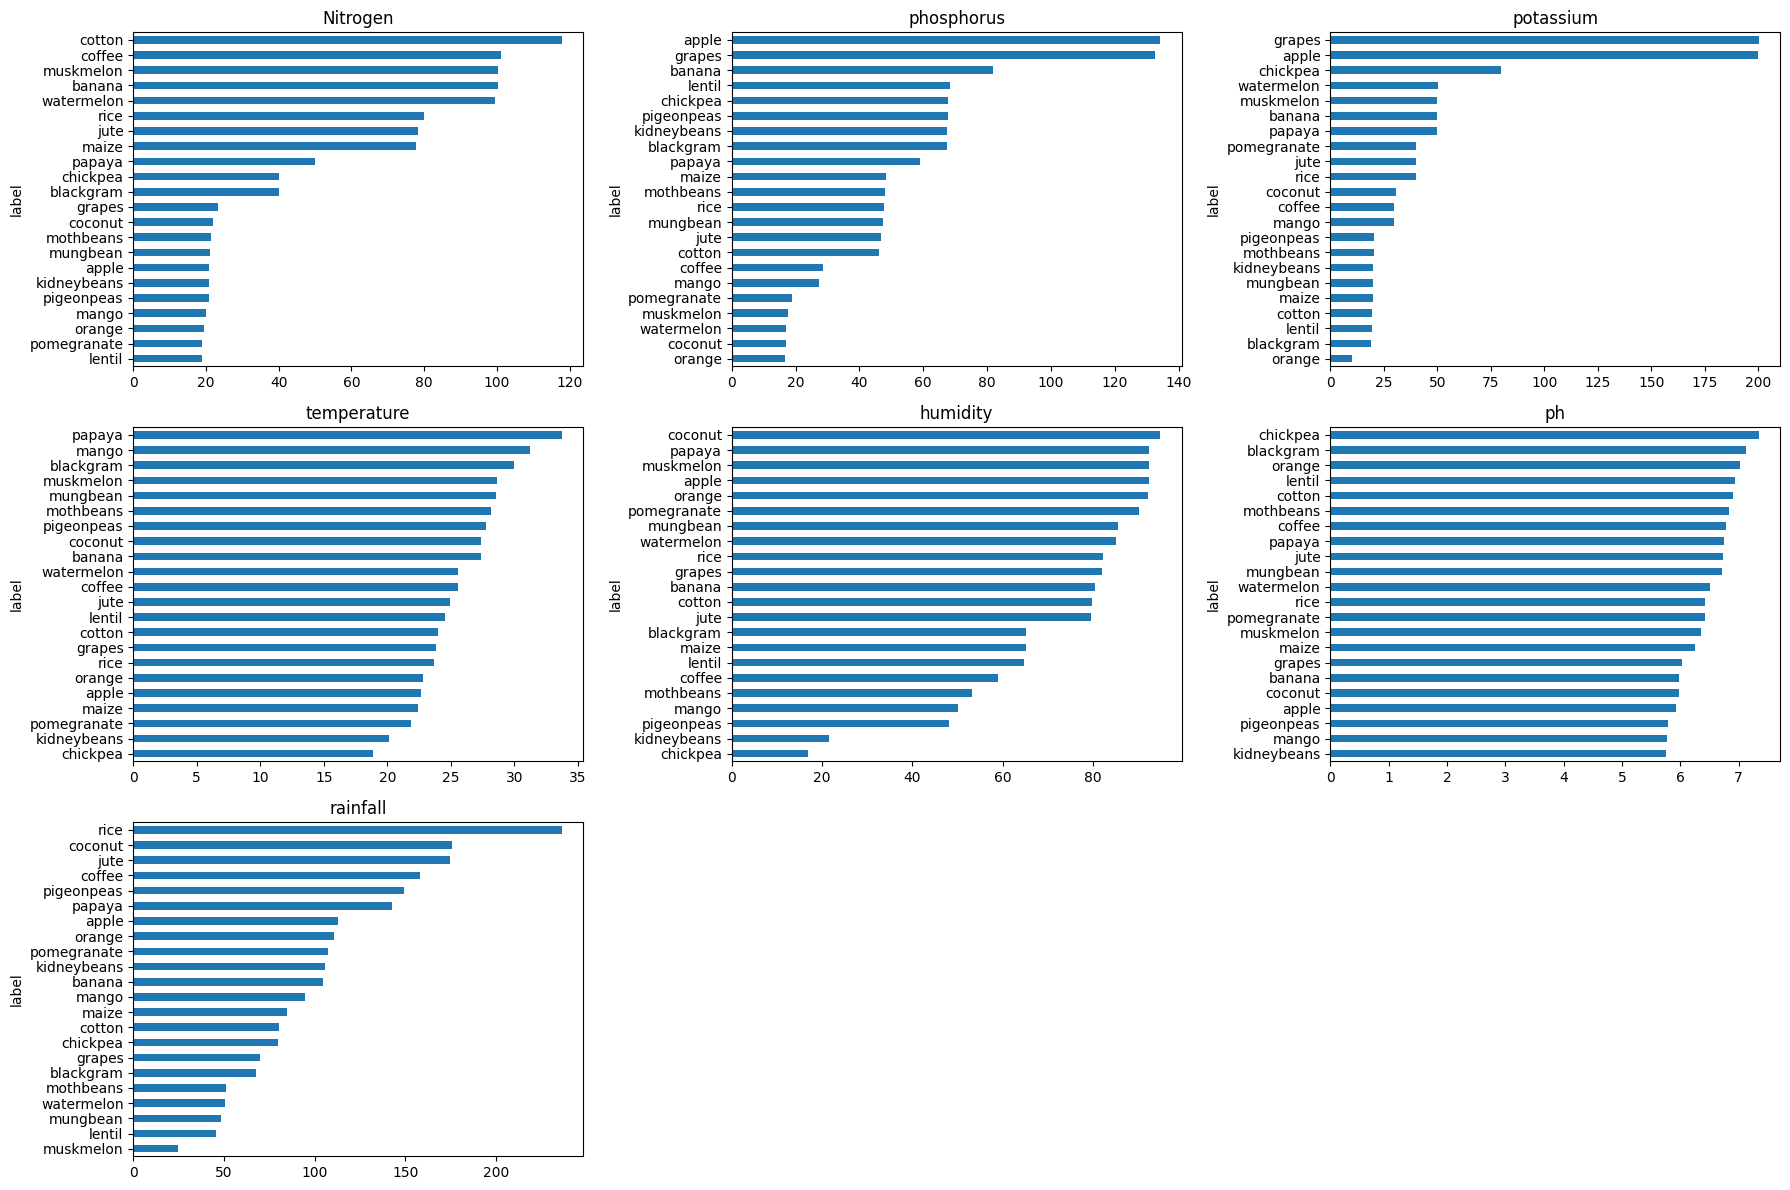

In [143]:
features_barh = grouped.columns

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(18, 12)
)

axes = axes.flatten()

for i, feature in enumerate(features_barh):
    grouped[feature].sort_values().plot(
        kind='barh',
        ax=axes[i],
        title=feature
    )
for i in range(len(features_barh), len(axes)):
  fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

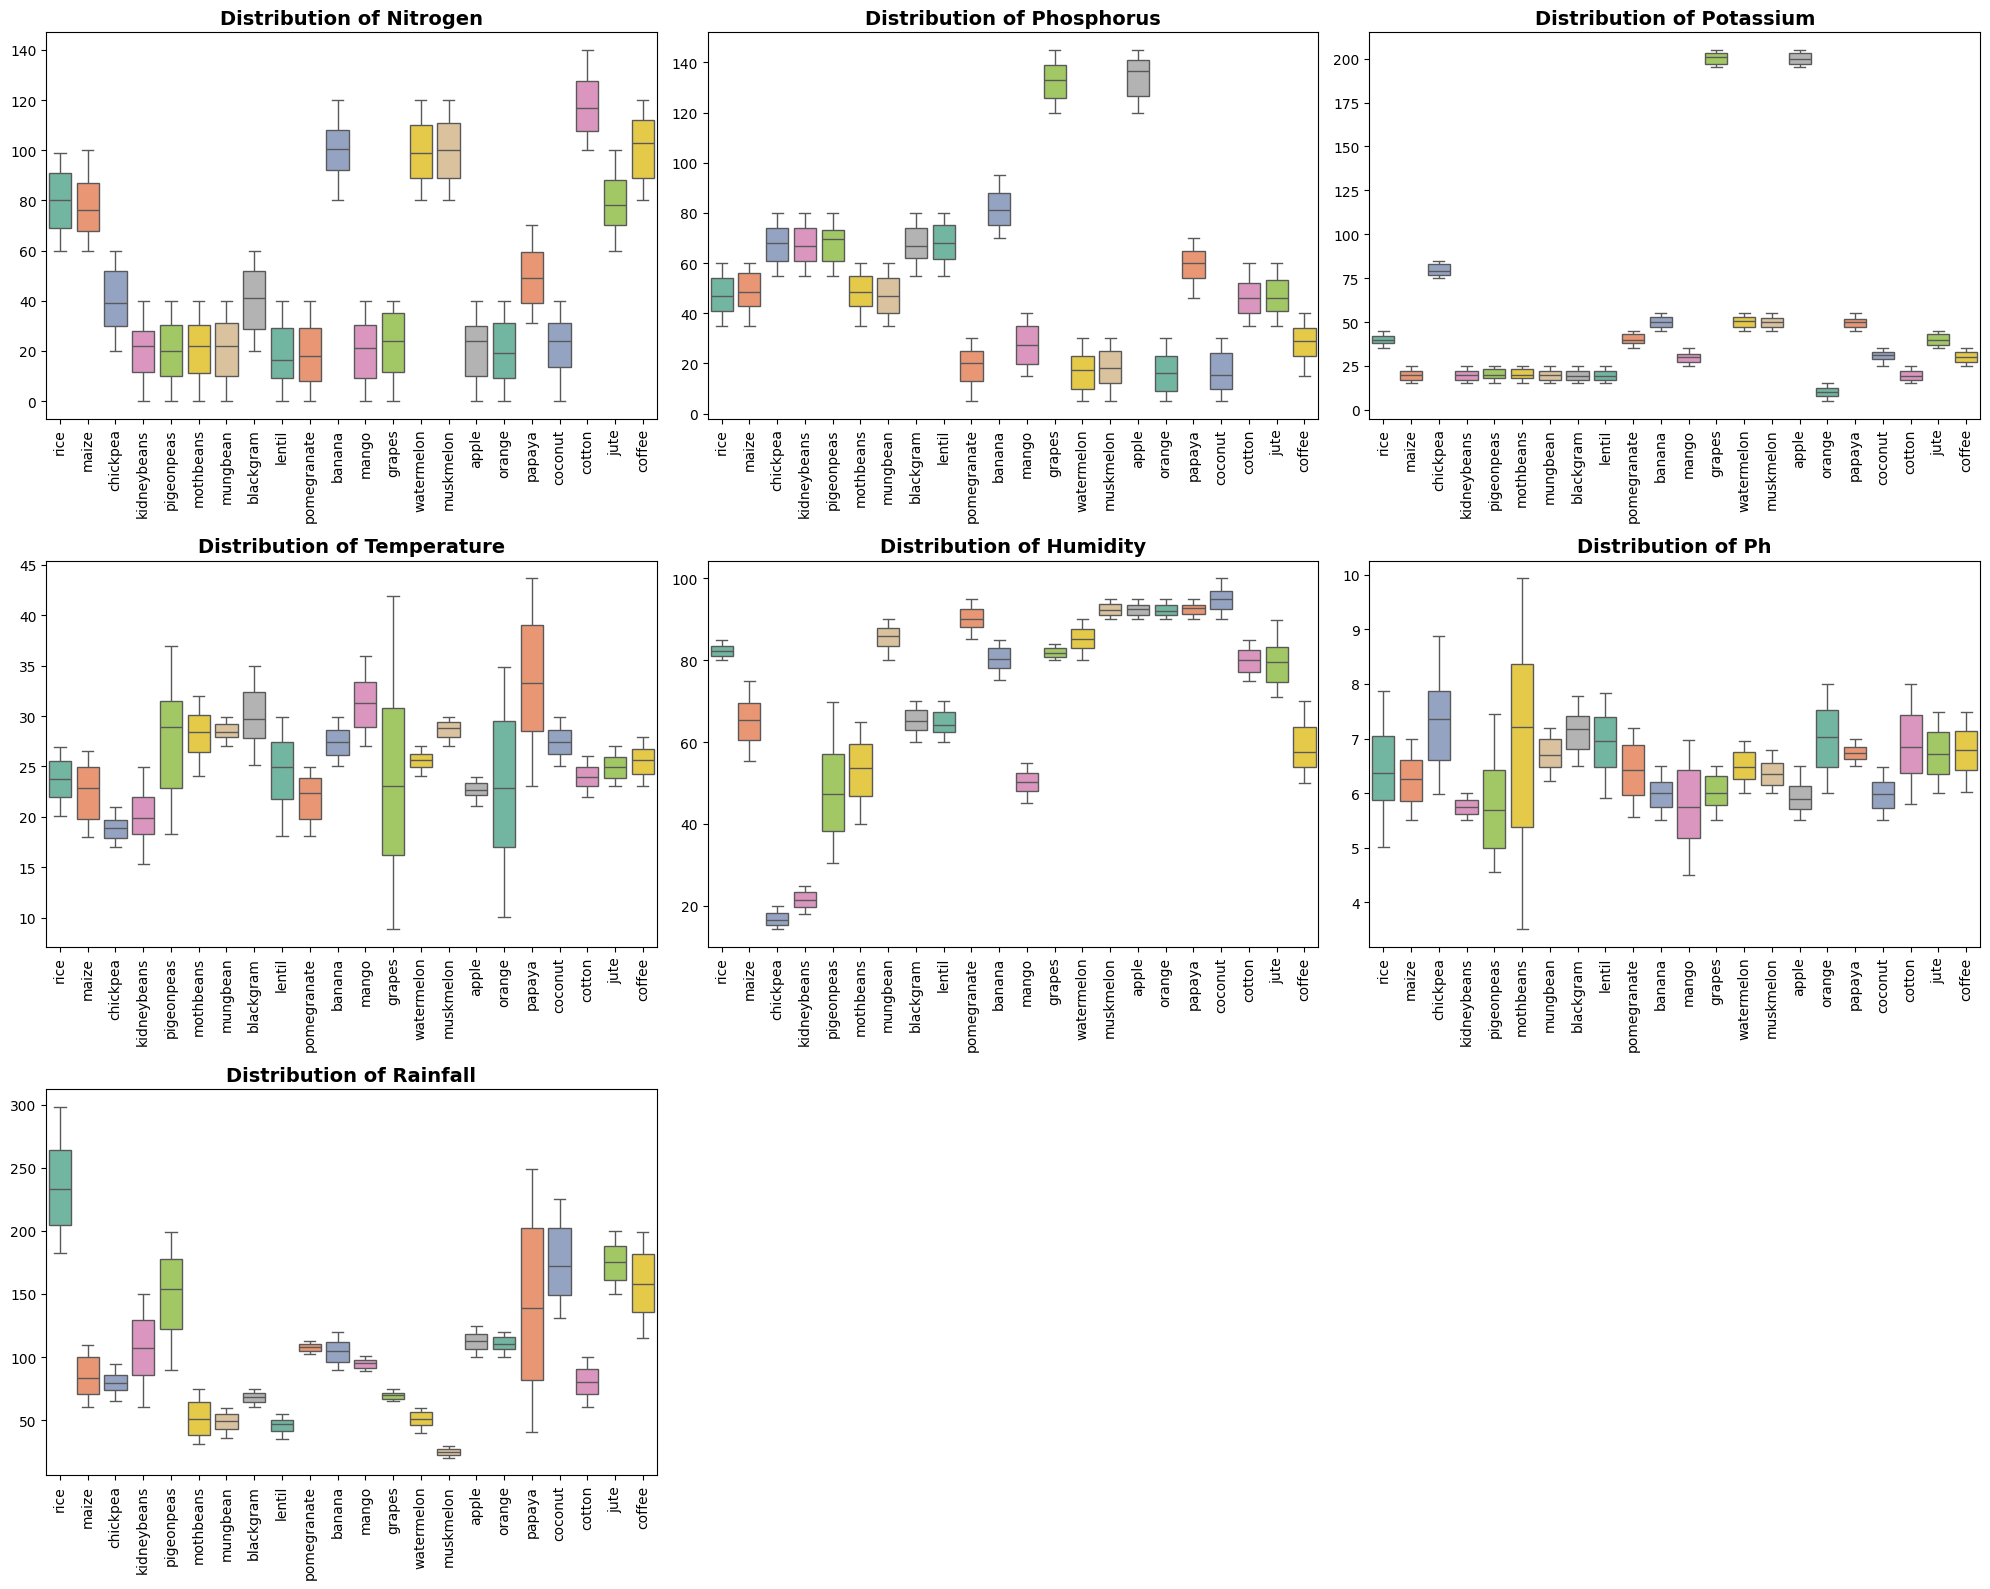

In [144]:
features_boxplot = new_df.drop('label', axis=1).columns

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 16))
axes = axes.flatten()

for i, feature in enumerate(features_boxplot):
    sns.boxplot(x='label', y=feature, data=new_df, ax=axes[i], palette='Set2', hue='label', legend=False)

    axes[i].set_title(f'Distribution of {feature.capitalize()}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', rotation=90)

for i in range(len(features_boxplot), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

## **3. Theory for some distance metrics**

### **1. Euclidean distance**
**Euclidean Distance** is defined as the distance between two points in Euclidean space. To find the distance between two points, the length of the line segment that connects the two points should be measured.

- Formula:
$$
d(p,q)=\sqrt{(q_1-p_1)^2 + (q_2-p_2)^2}
$$

Read more: https://www.geeksforgeeks.org/maths/euclidean-distance/

### **2. Manhattan Distance (L1)**

Measures how far apart two points are by summing the absolute differences of their coordinates. Calculates distance along grid-like paths like a taxi navigating city streets rather than cutting through buildings.

- For 2 dimensions: $|x_1 - x_2| + |y_1 - y_2|$

- For 3 dimensions: $|x_1 - x_2| + |y_1 - y_2| + |z_1 - z_2|$

- For n dimensions: $\sum_{i=1}^{n} |x_i - y_i| = |x_1 - y_1| + |x_2 - y_2| + \cdots + |x_n - y_n|$

Read more: https://www.geeksforgeeks.org/data-science/manhattan-distance/


### **3. Cosine similarity**
Measure similarity between two vectors by calculating cosine of angle between them.

A smaller distance indicates a higher similarity, while a larger distance indicates a lower similarity.

- Formula:
$$CS(\vec{x}, \vec{y})
=
\frac{\vec{x}\cdot\vec{y}}
{\|\vec{x}\|\|\vec{y}\|}
=
\frac{\sum_{i=1}^{n} x_i y_i}
{\sqrt{\sum_{i=1}^{n} x_i^2}\sqrt{\sum_{i=1}^{n} y_i^2}}$$

Read more: https://www.geeksforgeeks.org/dbms/cosine-similarity/

and slide **M02W02-Linear Algebra in application for AI (10/7/2026)**

## **4. Theory for Evaluation metrics**

### **1. Precision@K**
Commonly used evaluation metric in information retrieval, recommendation systems, and ranking tasks.

Precision@K measures the proportion of relevant items among the top-K retrieved results.


$$
Precision@K =
\frac{\text{Number of relevant items in the Top-K results}}{K}
$$

Where:

- **Number of relevant items in the Top-K results**: the number of retrieved items that are actually relevant to the query.
- **K**: the number of retrieved items considered.

Example:

Suppose the system returns the following Top-5 recommendations though **8** relevants item given in the dataset:

| Rank | Item | Relevant |
|------|------|----------|
| 1 | A | 1 |
| 2 | B | 1 |
| 3 | C | 0 |
| 4 | D | 1 |
| 5 | E | 0 |

There are 3 relevant items in the Top-5 results.

$$
Precision@5 = \frac{3}{5} = 0.6
$$

This means that 60% of the recommended items are relevant.

Read more: https://aiml.com/what-is-precisionk/

### **2. Recall@K**
Recall@K measures the proportion of relevant items that are successfully retrieved within the top-K results.

$$
Recall@K =
\frac{\text{Number of relevant items in the Top-K results}}
{\text{Total number of relevant items}}
$$

Where:

- **Number of relevant items in the Top-K results**: the number of retrieved items that are actually relevant to the query.
- **Total number of relevant items**: the total number of relevant items available in the dataset.

Example:

Suppose there are 8 relevant items in the dataset for a given query.

The system returns the following Top-5 results:

| Rank | Item | Relevant |
|------|------|----------|
| 1 | A | 1 |
| 2 | B | 1 |
| 3 | C | 0 |
| 4 | D | 1 |
| 5 | E | 0 |

There are 3 relevant items in the Top-5 results.

$$
Recall@5 = \frac{3}{8} = 0.375
$$

This means that the system successfully retrieved 37.5% of all relevant items.

Read more: https://www.evidentlyai.com/ranking-metrics/precision-recall-at-k

### **3. MAP (Mean Average Precision)**
Related to $Precision@K$

Read more: https://www.evidentlyai.com/ranking-metrics/mean-average-precision-map

## **Splitting data**

In [145]:
X = new_df.iloc[:, :-1].values
y = new_df.iloc[:, 7].values

from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.125,
    random_state=42,
    stratify=y_train_val,
)

print("Size Train:", X_train.shape)
print("Size Validation:", X_val.shape)
print("Size Test:", X_test.shape)
class_split_check = pd.concat([
    pd.Series(y).value_counts().rename("total"),
    pd.Series(y_train).value_counts().rename("train"),
    pd.Series(y_val).value_counts().rename("validation"),
    pd.Series(y_test).value_counts().rename("test"),
], axis=1).sort_index()

class_split_check["check"] = (
    class_split_check["train"]
    + class_split_check["validation"]
    + class_split_check["test"]
)

display(class_split_check)

Size Train: (1540, 7)
Size Validation: (220, 7)
Size Test: (440, 7)


,total,train,validation,test,check
apple,100,70,10,20,100
banana,100,70,10,20,100
blackgram,100,70,10,20,100
chickpea,100,70,10,20,100
coconut,100,70,10,20,100
coffee,100,70,10,20,100
cotton,100,70,10,20,100
grapes,100,70,10,20,100
jute,100,70,10,20,100
kidneybeans,100,70,10,20,100


In [146]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## **5. PCA Analysis**

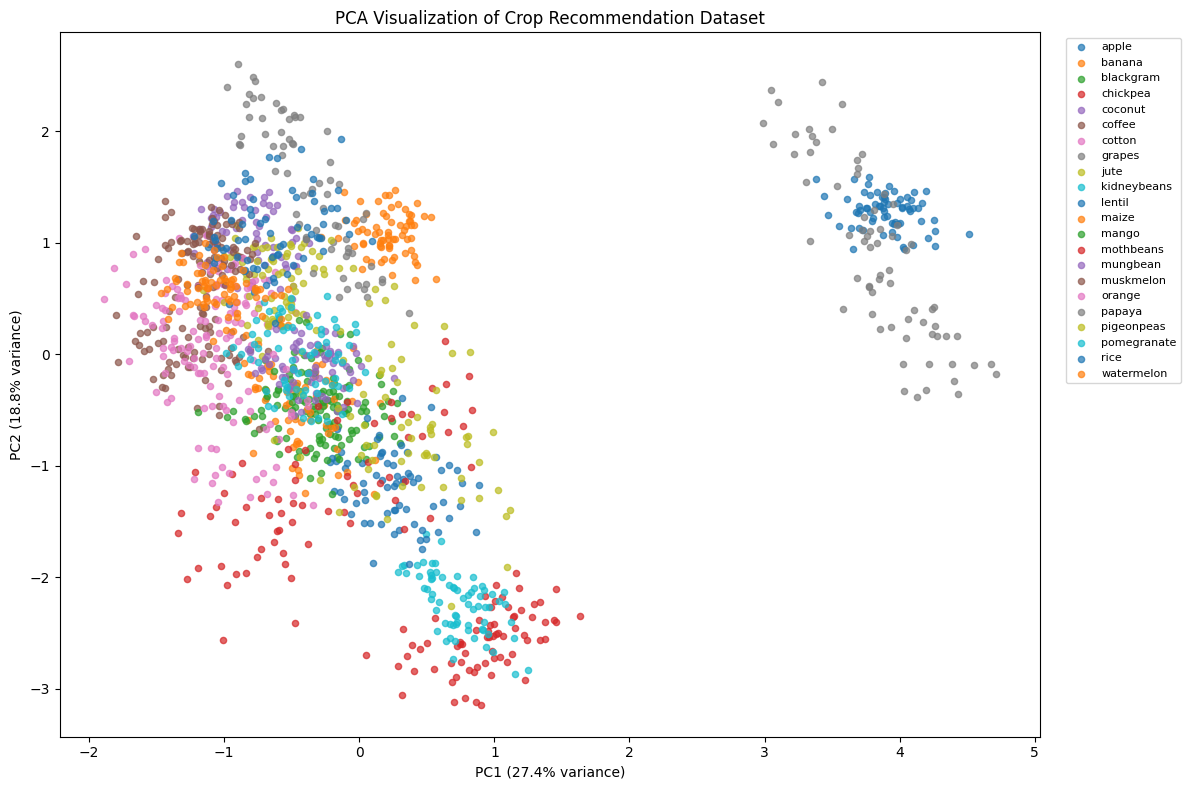

In [147]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_train)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "label": y_train
})

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for crop in sorted(pca_df["label"].unique()):

    subset = pca_df[pca_df["label"] == crop]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=20,
        alpha=0.7,
        label=crop
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)"
)

plt.title("PCA Visualization of Crop Recommendation Dataset")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()

plt.show()

## **6. Model**

Create abstract class for model

In [148]:
class BaseSearchModel:

    def fit(self, X, y):
        pass

    def search(self, X_query):
        pass

### **6.1 Model 1 - KNN Base**

In [149]:
class KNNModel(BaseSearchModel):

    def __init__(self, metric, n_neighbors, **kwargs):

        self.metric = metric
        self.n_neighbors = n_neighbors

    def fit(self, X_train, y_train):

        self.X_train = X_train
        self.y_train = y_train

        self.model = NearestNeighbors(
            metric=self.metric,
            n_neighbors=self.n_neighbors
        )

        self.model.fit(X_train)

    def search(self, X_query):

        distances, indices = self.model.kneighbors(X_query)

        return distances, indices

### **6.2 Model 2 - KNN + Kmeans search optimizer**

In [150]:
class KMeansKNNModel(BaseSearchModel):

    def __init__(
        self,
        metric="euclidean",
        n_neighbors=5,
        n_clusters=20,
        random_state=42
    ):

        self.metric = metric
        self.n_neighbors = n_neighbors
        self.n_clusters = n_clusters
        self.random_state = random_state


    def fit(self, X_train, y_train):

        self.X_train = X_train
        self.y_train = y_train

        self.kmeans = KMeans(
            n_clusters=self.n_clusters,
            random_state=self.random_state
        )

        self.cluster_labels = self.kmeans.fit_predict(X_train)

        self.cluster_to_indices = {}
        self.cluster_knn = {}

        for idx, cluster in enumerate(self.cluster_labels):
            self.cluster_to_indices.setdefault(cluster, []).append(idx)

        for cluster, indices in self.cluster_to_indices.items():

            candidate_vectors = self.X_train[indices]

            knn = NearestNeighbors(
                metric=self.metric,
                n_neighbors=min(self.n_neighbors, len(candidate_vectors))
            )

            knn.fit(candidate_vectors)
            self.cluster_knn[cluster] = knn


    def search(self, X_query):

        all_distances = []
        all_indices = []
        query_clusters = self.kmeans.predict(X_query)

        for query, cluster in zip(X_query, query_clusters):

            query = query.reshape(1, -1)
            candidate_indices = self.cluster_to_indices[cluster]
            knn = self.cluster_knn[cluster]
            distances, local_indices = knn.kneighbors(query)

            global_indices = np.array(
                [candidate_indices[i] for i in local_indices[0]]
            )

            all_distances.append(distances[0])
            all_indices.append(global_indices)

        return np.array(all_distances), np.array(all_indices)

## **7. Evaluation metrics**

### **7.1 Helper functions on precision, recall, AP, MAP, NDCG at Top-K and run model**

In [151]:
def precision_at_k(recommended_labels, actual_label, k):
    """
    recommended_labels: Top-K labels returned by the model
    actual_label: Ground truth label
    """

    top_k = recommended_labels[:k]

    relevant = np.sum(top_k == actual_label)

    return relevant / k

def recall_at_k(recommended_labels, actual_label, total_relevant, k):
    """
    total_relevant:
        Number of training samples having the same label
    """

    top_k = recommended_labels[:k]
    relevant = np.sum(top_k == actual_label)

    return relevant / total_relevant

def average_precision_at_k(recommended_labels, actual_label, total_relevant, k):
    top_k = recommended_labels[:k]
    hits = 0
    ap = 0

    for i, label in enumerate(top_k):
        if label == actual_label:
            hits += 1
            ap += hits / (i + 1)

    if hits == 0:
        return 0

    return ap / min(total_relevant, k)

def dcg_at_k(recommended_labels, actual_label, k):
    dcg = 0

    for i, label in enumerate(recommended_labels[:k]):
        if label == actual_label:
            dcg += 1 / np.log2(i + 2)
    return dcg

def ndcg_at_k(recommended_labels, actual_label, total_relevant, k):

    dcg = dcg_at_k(
        recommended_labels,
        actual_label,
        k
    )

    ideal_hits = min(total_relevant, k)

    idcg = sum(
        1 / np.log2(i + 2)
        for i in range(ideal_hits)
    )

    if idcg == 0:
        return 0

    return dcg / idcg

In [153]:
def run_model(model, X_train, y_train, X_query, y_query, top_k):
    model.fit(X_train, y_train)
    return evaluate(model=model, X_query=X_query, y_query=y_query, y_train= y_train, top_k=top_k)

def run_baseline_knn(distances, X_train, y_train, X_val, y_val, top_k):
    results = []

    for metric in distances:

        model = KNNModel(
            metric=metric,
            n_neighbors=top_k
        )

        scores = run_model(
            model,
            X_train,
            y_train,
            X_val,
            y_val,
            top_k
        )

        results.append({
            "Model": "KNN",
            "Distance": metric,
            "Clusters": "-",
            **scores
        })

    return results

def run_knn_kmeans_optimizer(distances, n_clusters, X_train, y_train, X_val, y_val, top_k):
    results = []
    history = []
    for metric in distances:

        best_map = -1

        for cluster in n_clusters:

            model = KMeansKNNModel(
                metric=metric,
                n_neighbors=top_k,
                n_clusters=cluster
            )

            scores = run_model(
                model,
                X_train,
                y_train,
                X_val,
                y_val,
                top_k
            )

            history.append({
                "Distance": metric,
                "Clusters": cluster,
                "MAP": scores["MAP"],
                "Precision@K": scores["Precision@K"],
                "Recall@K": scores["Recall@K"],
                "NDCG@K": scores["NDCG@K"],
                "Search Time (s)": scores["Search Time (s)"]
            })

            if scores["MAP"] > best_map:

                best_map = scores["MAP"]

                best = {
                    "Model": "KMeans+KNN",
                    "Distance": metric,
                    "Clusters": cluster,
                    **scores
                }

        results.append(best)

    return results, pd.DataFrame(history)

### **7.2 Evaluate function**

In [152]:
def evaluate(model, X_query, y_query, y_train, top_k):
    start = time.perf_counter()
    distances, indices = model.search(X_query)
    search_time = time.perf_counter() - start
    precisions = []
    recalls = []
    maps = []
    ndcgs = []

    for i in range(len(X_query)):

        # Top-K neighbor indices
        neighbor_indices = indices[i]

        # Convert index -> label
        recommended_labels = y_train[neighbor_indices]

        # Ground truth
        actual_label = y_query[i]

        # Number of relevant items in training set
        total_relevant = np.sum(y_train == actual_label)

        precisions.append(
            precision_at_k(
                recommended_labels,
                actual_label,
                top_k
            )
        )

        recalls.append(
            recall_at_k(
                recommended_labels,
                actual_label,
                total_relevant,
                top_k
            )
        )

        maps.append(
            average_precision_at_k(
                recommended_labels,
                actual_label,
                total_relevant,
                top_k
            )
        )

        ndcgs.append(
            ndcg_at_k(
                recommended_labels,
                actual_label,
                total_relevant,
                top_k
            )
        )

    return {
        "Precision@K": np.mean(precisions),
        "Recall@K": np.mean(recalls),
        "MAP": np.mean(maps),
        "NDCG@K": np.mean(ndcgs),
        "Search Time (s)": search_time,
        "Avg Query Time (ms)": (search_time / len(X_query)) * 1000
    }

## **8. Experimental on test, val and evaluate 2 models**

In [154]:
DISTANCES = [
    "euclidean",
    "manhattan",
    "cosine"
]

CLUSTERS = [5, 10, 15, 20, 30, 50]
TOP_K = 5

baseline_results = run_baseline_knn(
    DISTANCES,
    X_train,
    y_train,
    X_val,
    y_val,
    TOP_K
)

kmeans_results, tuning_history = run_knn_kmeans_optimizer(
    DISTANCES,
    CLUSTERS,
    X_train,
    y_train,
    X_val,
    y_val,
    TOP_K
)

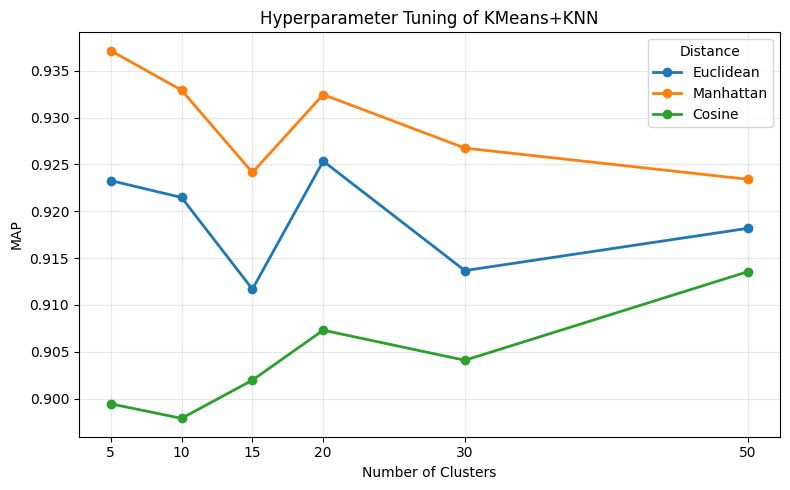

In [155]:
plt.figure(figsize=(8,5))

for metric in DISTANCES:

    subset = tuning_history[
        tuning_history["Distance"] == metric
    ]

    plt.plot(
        subset["Clusters"],
        subset["MAP"],
        marker="o",
        linewidth=2,
        label=metric.capitalize()
    )

plt.xlabel("Number of Clusters")
plt.ylabel("MAP")
plt.title("Hyperparameter Tuning of KMeans+KNN")
plt.xticks(CLUSTERS)
plt.grid(True, alpha=0.3)
plt.legend(title="Distance")
plt.tight_layout()

plt.show()

In [156]:
comparison = pd.DataFrame(
    baseline_results + kmeans_results
)

display(comparison)

,Model,Distance,Clusters,Precision@K,Recall@K,MAP,NDCG@K,Search Time (s),Avg Query Time (ms)
0,KNN,euclidean,-,0.941818,0.067273,0.927697,0.944518,0.005209,0.023678
1,KNN,manhattan,-,0.955455,0.068247,0.941455,0.956240,0.006479,0.029452
2,KNN,cosine,-,0.918182,0.065584,0.902894,0.922508,0.018160,0.082546
3,KMeans+KNN,euclidean,20,0.936364,0.066883,0.925348,0.939933,0.171260,0.778453
4,KMeans+KNN,manhattan,5,0.950909,0.067922,0.937136,0.952775,0.162844,0.740199
5,KMeans+KNN,cosine,50,0.927273,0.066234,0.913561,0.929606,0.205938,0.936080


In [157]:
best_model = KNNModel(
    metric="manhattan",
    n_neighbors=TOP_K
)

best_model.fit(X_train, y_train)

test_scores = evaluate(
    model=best_model,
    X_query=X_test,
    y_query=y_test,
    y_train=y_train,
    top_k=TOP_K
)

display(test_scores)

{'Precision@K': np.float64(0.9559090909090909),
 'Recall@K': np.float64(0.06827922077922076),
 'MAP': np.float64(0.9435833333333332),
 'NDCG@K': np.float64(0.9603339361525488),
 'Search Time (s)': 0.00867509500039887,
 'Avg Query Time (ms)': 0.01971612500090652}